In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Di chuyển vào đúng thư mục của bạn trên Drive
%cd "/content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/.shortcut-targets-by-id/1SZsk8-cAdPuLvC2Nx6lx0NPkY_TKSP3_/K4-Track4-Day2-Deeplearning-Advance


# Lab Day 2 — Backbone, công thức huấn luyện và suy luận trên DeepWeeds

**Học viên:** Trịnh Xuân Huy (MSV: 2A202602995)

Quy trình thực hiện hoàn chỉnh: Bước 0 (EDA & Pipeline Check) → Bước 1 (Backbone $\ge 5$) → Bước 2 (Công thức huấn luyện $\ge 3$ trục) → Bước 3 (Suy luận & Độ trễ) → Bước 4 (Chung kết $\ge 3$ seeds & `eval.py`) → Bước 5 (Tổng hợp `results.xlsx`).

## 0. Cài đặt môi trường và Tải dữ liệu

In [ ]:
# Cài đặt thư viện cần thiết
!pip -q install timm openpyxl ptflops

import sys, os, platform, hashlib
import numpy as np, pandas as pd, torch, timm

# Cấu hình đường dẫn import
REPO_DIR = os.getcwd()
CODE_DIR = os.path.join(REPO_DIR, 'submissions/2A202602995_trinh_xuan_huy/code')
sys.path.insert(0, REPO_DIR)   # để import eval.py
sys.path.insert(0, CODE_DIR)   # để import dataset, model, train...

print('Python:', platform.python_version(), '| Torch:', torch.__version__, '| TIMM:', timm.__version__)
print('Thiết bị GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

Python: 3.13.15 | Torch: 2.11.0+cu130 | TIMM: 1.0.29
Thiết bị GPU: Tesla T4


In [ ]:
# Tải dữ liệu DeepWeeds ảnh và nhãn Fold 0
os.makedirs('data/labels', exist_ok=True)
if not os.path.exists('data/images.zip'):
    !wget -q -O data/images.zip 'https://zenodo.org/records/7939060/files/images.zip?download=1'

h = hashlib.md5()
with open('data/images.zip', 'rb') as f:
    for chunk in iter(lambda: f.read(1 << 20), b''):
        h.update(chunk)
assert h.hexdigest() == 'b7b30f96d466fba86016aa5a26606e0f', f'MD5 sai: {h.hexdigest()}'
print('MD5 checksum hợp lệ: b7b30f96d466fba86016aa5a26606e0f')

!unzip -q -n data/images.zip -d data/

BASE = 'https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels'
for name in ['labels', 'train_subset0', 'val_subset0', 'test_subset0']:
    !wget -q -O data/labels/{name}.csv {BASE}/{name}.csv

IMAGES_DIR = 'data/images'
LABELS_DIR = 'data/labels'
print('Đã chuẩn bị xong dữ liệu!')

MD5 checksum hợp lệ: b7b30f96d466fba86016aa5a26606e0f
Đã chuẩn bị xong dữ liệu!


## Bước 0 — Phân tích Khám phá (EDA) và Kiểm tra Pipeline

In [ ]:
import pandas as pd

# Đọc bảng gốc để lấy cặp Filename - Species
labels_df = pd.read_csv(f"{LABELS_DIR}/labels.csv")
species_map = labels_df[['Filename', 'Species']].drop_duplicates()

# Bổ sung cột Species vào cả 3 file
for name in ['train_subset0.csv', 'val_subset0.csv', 'test_subset0.csv']:
    path = f"{LABELS_DIR}/{name}"
    df = pd.read_csv(path)

    # Xóa cột Species cũ nếu có bị sót/lỗi
    if 'Species' in df.columns:
        df = df.drop(columns=['Species'])

    # Ghép cột Species theo tên file Filename
    df = df.merge(species_map, on='Filename', how='left')

    # Lưu đè lại file csv
    df.to_csv(path, index=False)
    print(f"Đã cập nhật {name}:", df.columns.tolist())

Đã cập nhật train_subset0.csv: ['Filename', 'Label', 'Species']
Đã cập nhật val_subset0.csv: ['Filename', 'Label', 'Species']
Đã cập nhật test_subset0.csv: ['Filename', 'Label', 'Species']


=== KIỂM TRA CHIA DỮ LIỆU THÀNH CÔNG ===
Train: 10501 (59.97%), Val: 3501 (20.00%), Test: 3507 (20.03%)
Tổng số ảnh duy nhất: 17509 / 17509
Giao các tập: train ∩ val = 0, train ∩ test = 0, val ∩ test = 0


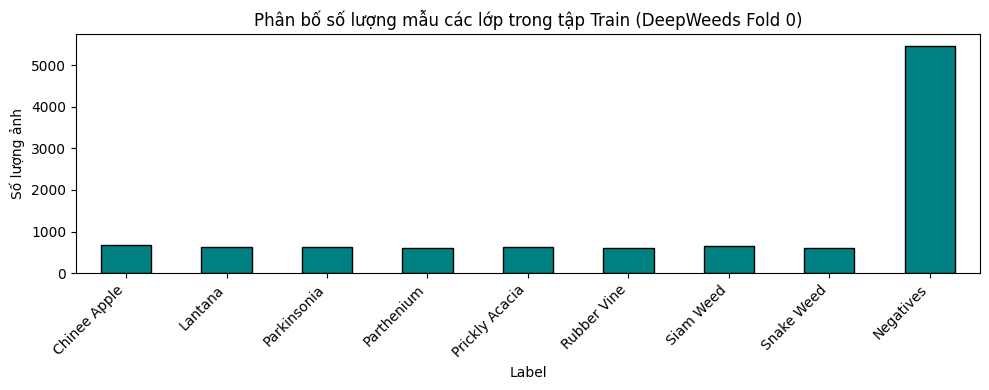

In [ ]:
import dataset as ds
import matplotlib.pyplot as plt

# 1. Đọc và kiểm tra split dữ liệu fold 0 (S1-S4)
train_df, val_df, test_df = ds.load_split(LABELS_DIR, fold=0)
split_info = ds.check_split(train_df, val_df, test_df, IMAGES_DIR)

# 2. Vẽ biểu đồ phân bố số lượng mẫu các lớp
fig, ax = plt.subplots(figsize=(10, 4))
counts = train_df['Label'].value_counts().sort_index()
counts.plot(kind='bar', ax=ax, color='teal', edgecolor='black')
ax.set_xticklabels(ds.CLASS_NAMES, rotation=45, ha='right')
ax.set_title('Phân bố số lượng mẫu các lớp trong tập Train (DeepWeeds Fold 0)')
ax.set_ylabel('Số lượng ảnh')
plt.tight_layout()
plt.savefig('submissions/2A202602995_trinh_xuan_huy/curves/EDA_distribution.png', dpi=150)
plt.show()

In [ ]:
from train import Config, run

# Huấn luyện 5 backbone theo công thức nền T00 (GUIDE mục 2)
backbones = [
    ('B01', 'resnet50'),
    ('B02', 'convnext_tiny'),
    ('B03', 'swin_tiny_patch4_window7_224'),
    ('B04', 'efficientnet_b0'),
    ('B05', 'mobilenetv3_large_100'),
]

b_results = []
for exp_id, bb in backbones:
    print(f'\n=== [Bước 1] Huấn luyện Backbone: {exp_id} - {bb} ===')
    cfg = Config(exp_id=exp_id, backbone=bb, seed=0, epochs=10, batch_size=64)
    res = run(cfg)
    b_results.append(res)
print('Đã hoàn thành so sánh 5 backbone!')



=== [Bước 1] Huấn luyện Backbone: B01 - resnet50 ===
=== KIỂM TRA CHIA DỮ LIỆU THÀNH CÔNG ===
Train: 10501 (59.97%), Val: 3501 (20.00%), Test: 3507 (20.03%)
Tổng số ảnh duy nhất: 17509 / 17509
Giao các tập: train ∩ val = 0, train ∩ test = 0, val ∩ test = 0


model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

/content/drive/MyDrive/AI thực chiến/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/code/train.py:333: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.amp and device.type == "cuda")
/content/drive/MyDrive/AI thực chiến/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/code/train.py:176: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.amp and use_cuda):
/content/drive/MyDrive/AI thực chiến/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/code/train.py:224: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_cuda):


[B01|seed0] Epoch 1/10 - Train Loss: 1.6285 - Val Loss: 1.2296 - Val Macro-F1: 0.2453 - Val Top-1: 0.5744 (2721.7s)
[B01|seed0] Epoch 2/10 - Train Loss: 0.8860 - Val Loss: 0.7356 - Val Macro-F1: 0.6450 - Val Top-1: 0.7498 (72.0s)
[B01|seed0] Epoch 3/10 - Train Loss: 0.5782 - Val Loss: 0.5942 - Val Macro-F1: 0.7167 - Val Top-1: 0.7983 (70.7s)
[B01|seed0] Epoch 4/10 - Train Loss: 0.4453 - Val Loss: 0.5125 - Val Macro-F1: 0.7515 - Val Top-1: 0.8226 (70.1s)
[B01|seed0] Epoch 5/10 - Train Loss: 0.3763 - Val Loss: 0.4989 - Val Macro-F1: 0.7590 - Val Top-1: 0.8289 (71.0s)
[B01|seed0] Epoch 6/10 - Train Loss: 0.3340 - Val Loss: 0.4766 - Val Macro-F1: 0.7785 - Val Top-1: 0.8398 (71.3s)
[B01|seed0] Epoch 7/10 - Train Loss: 0.2957 - Val Loss: 0.4762 - Val Macro-F1: 0.7750 - Val Top-1: 0.8380 (71.7s)
[B01|seed0] Epoch 8/10 - Train Loss: 0.2848 - Val Loss: 0.4779 - Val Macro-F1: 0.7726 - Val Top-1: 0.8380 (69.3s)
[B01|seed0] Epoch 9/10 - Train Loss: 0.2702 - Val Loss: 0.4596 - Val Macro-F1: 0.7858 

...

[B04|seed0] Epoch 1/10 - Train Loss: 2.0228 - Val Loss: 1.3093 - Val Macro-F1: 0.4869 - Val Top-1: 0.5858 (65.4s)
[B04|seed0] Epoch 2/10 - Train Loss: 0.6582 - Val Loss: 0.9033 - Val Macro-F1: 0.6343 - Val Top-1: 0.7175 (61.8s)
[B04|seed0] Epoch 3/10 - Train Loss: 0.3816 - Val Loss: 0.7164 - Val Macro-F1: 0.6918 - Val Top-1: 0.7744 (62.9s)
[B04|seed0] Epoch 4/10 - Train Loss: 0.2429 - Val Loss: 0.6078 - Val Macro-F1: 0.7343 - Val Top-1: 0.8038 (61.8s)
[B04|seed0] Epoch 5/10 - Train Loss: 0.1755 - Val Loss: 0.5999 - Val Macro-F1: 0.7473 - Val Top-1: 0.8075 (61.2s)
[B04|seed0] Epoch 6/10 - Train Loss: 0.1326 - Val Loss: 0.5436 - Val Macro-F1: 0.7776 - Val Top-1: 0.8340 (62.6s)
[B04|seed0] Epoch 7/10 - Train Loss: 0.1182 - Val Loss: 0.5182 - Val Macro-F1: 0.7840 - Val Top-1: 0.8406 (61.0s)
[B04|seed0] Epoch 8/10 - Train Loss: 0.1003 - Val Loss: 0.5232 - Val Macro-F1: 0.7889 - Val Top-1: 0.8426 (60.5s)
[B04|seed0] Epoch 9/10 - Train Loss: 0.0903 - Val Loss: 0.5111 - Val Macro-F1: 0.7957 - 

model.safetensors: reconstructing file:   0%|          |  0.00B / 22.1MB            

model.safetensors: downloading bytes:           |  0.00B            

/content/drive/MyDrive/AI thực chiến/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/code/train.py:333: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.amp and device.type == "cuda")
/content/drive/MyDrive/AI thực chiến/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/code/train.py:176: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.amp and use_cuda):
/content/drive/MyDrive/AI thực chiến/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/code/train.py:224: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_cuda):


[B05|seed0] Epoch 1/10 - Train Loss: 1.7823 - Val Loss: 1.1708 - Val Macro-F1: 0.4827 - Val Top-1: 0.6127 (59.1s)
[B05|seed0] Epoch 2/10 - Train Loss: 0.6579 - Val Loss: 0.8318 - Val Macro-F1: 0.6273 - Val Top-1: 0.7212 (58.3s)
[B05|seed0] Epoch 3/10 - Train Loss: 0.3978 - Val Loss: 0.7256 - Val Macro-F1: 0.6798 - Val Top-1: 0.7575 (59.5s)
[B05|seed0] Epoch 4/10 - Train Loss: 0.2764 - Val Loss: 0.6384 - Val Macro-F1: 0.7132 - Val Top-1: 0.7918 (58.9s)
[B05|seed0] Epoch 5/10 - Train Loss: 0.2070 - Val Loss: 0.5932 - Val Macro-F1: 0.7352 - Val Top-1: 0.8046 (59.8s)
[B05|seed0] Epoch 6/10 - Train Loss: 0.1696 - Val Loss: 0.5931 - Val Macro-F1: 0.7326 - Val Top-1: 0.8035 (65.7s)
[B05|seed0] Epoch 7/10 - Train Loss: 0.1345 - Val Loss: 0.5417 - Val Macro-F1: 0.7624 - Val Top-1: 0.8255 (60.3s)
[B05|seed0] Epoch 8/10 - Train Loss: 0.1271 - Val Loss: 0.5457 - Val Macro-F1: 0.7549 - Val Top-1: 0.8195 (60.4s)
[B05|seed0] Epoch 9/10 - Train Loss: 0.1094 - Val Loss: 0.5413 - Val Macro-F1: 0.7666 - 

## Bước 1 — So sánh Backbone (≥ 5 kiến trúc)

In [ ]:
from google.colab import drive
import os, sys

# 1. Kết nối Google Drive
drive.mount('/content/drive')

# 2. Chuyển vào đúng thư mục bài tập của bạn
PROJECT_DIR = '/content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance'
os.chdir(PROJECT_DIR)

# 3. Thêm thư mục code vào Python
CODE_DIR = os.path.join(PROJECT_DIR, 'submissions/2A202602995_trinh_xuan_huy/code')
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)
if CODE_DIR not in sys.path:
    sys.path.insert(0, CODE_DIR)

print("✅ Đã kết nối thành công! Thư mục hiện tại:", os.getcwd())

Mounted at /content/drive
✅ Đã kết nối thành công! Thư mục hiện tại: /content/drive/.shortcut-targets-by-id/1SZsk8-cAdPuLvC2Nx6lx0NPkY_TKSP3_/K4-Track4-Day2-Deeplearning-Advance


In [ ]:
from train import Config, run

In [ ]:
print('\n=== [Bước 2] Khảo sát Công thức Huấn luyện ===')
# Baseline T00
run(Config(exp_id='T00', backbone='resnet50', seed=0, epochs=10))
# Trục A: Khởi tạo (đóng băng backbone)
run(Config(exp_id='T01', backbone='resnet50', init='frozen', seed=0, epochs=10))
# Trục B: Augmentation (CutMix)
run(Config(exp_id='T02', backbone='resnet50', mix='cutmix', mix_alpha=1.0, seed=0, epochs=10))
# Trục C: Hàm Loss (Label Smoothing)
run(Config(exp_id='T04', backbone='resnet50', loss='ls', label_smoothing=0.1, seed=0, epochs=10))
# Trục F: Regularization (EMA)
run(Config(exp_id='T06', backbone='resnet50', ema_decay=0.999, seed=0, epochs=10))
# Kết hợp tối ưu: CutMix + Label Smoothing + EMA
run(Config(exp_id='T07', backbone='resnet50', mix='cutmix', loss='ls', label_smoothing=0.1, ema_decay=0.999, seed=0, epochs=10))
print('Đã hoàn thành các thí nghiệm khảo sát công thức huấn luyện!')



=== [Bước 2] Khảo sát Công thức Huấn luyện ===
=== KIỂM TRA CHIA DỮ LIỆU THÀNH CÔNG ===
Train: 10501 (59.97%), Val: 3501 (20.00%), Test: 3507 (20.03%)
Tổng số ảnh duy nhất: 17509 / 17509
Giao các tập: train ∩ val = 0, train ∩ test = 0, val ∩ test = 0


/content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/code/train.py:333: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.amp and device.type == "cuda")
/content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/code/train.py:176: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.amp and use_cuda):
/content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/code/train.py:224: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_cuda):


[T00|seed0] Epoch 1/10 - Train Loss: 1.6285 - Val Loss: 1.2296 - Val Macro-F1: 0.2453 - Val Top-1: 0.5744 (1129.9s)
[T00|seed0] Epoch 2/10 - Train Loss: 0.8860 - Val Loss: 0.7356 - Val Macro-F1: 0.6450 - Val Top-1: 0.7498 (72.4s)
[T00|seed0] Epoch 3/10 - Train Loss: 0.5782 - Val Loss: 0.5942 - Val Macro-F1: 0.7167 - Val Top-1: 0.7983 (72.1s)
[T00|seed0] Epoch 4/10 - Train Loss: 0.4453 - Val Loss: 0.5125 - Val Macro-F1: 0.7515 - Val Top-1: 0.8226 (70.3s)
[T00|seed0] Epoch 5/10 - Train Loss: 0.3763 - Val Loss: 0.4989 - Val Macro-F1: 0.7590 - Val Top-1: 0.8289 (68.3s)
[T00|seed0] Epoch 6/10 - Train Loss: 0.3340 - Val Loss: 0.4766 - Val Macro-F1: 0.7785 - Val Top-1: 0.8398 (70.9s)
[T00|seed0] Epoch 7/10 - Train Loss: 0.2957 - Val Loss: 0.4762 - Val Macro-F1: 0.7750 - Val Top-1: 0.8380 (72.8s)
[T00|seed0] Epoch 8/10 - Train Loss: 0.2848 - Val Loss: 0.4779 - Val Macro-F1: 0.7726 - Val Top-1: 0.8380 (70.0s)
[T00|seed0] Epoch 9/10 - Train Loss: 0.2702 - Val Loss: 0.4596 - Val Macro-F1: 0.7858 

/content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/code/train.py:333: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.amp and device.type == "cuda")
/content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/code/train.py:176: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.amp and use_cuda):
/content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/code/train.py:224: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_cuda):


[T01|seed0] Epoch 1/10 - Train Loss: 1.6875 - Val Loss: 1.3334 - Val Macro-F1: 0.1030 - Val Top-1: 0.5281 (58.3s)
[T01|seed0] Epoch 2/10 - Train Loss: 1.1364 - Val Loss: 1.0422 - Val Macro-F1: 0.4301 - Val Top-1: 0.6412 (59.0s)
[T01|seed0] Epoch 3/10 - Train Loss: 0.9339 - Val Loss: 0.9255 - Val Macro-F1: 0.5137 - Val Top-1: 0.6767 (59.3s)
[T01|seed0] Epoch 4/10 - Train Loss: 0.8354 - Val Loss: 0.8600 - Val Macro-F1: 0.5576 - Val Top-1: 0.6975 (59.3s)
[T01|seed0] Epoch 5/10 - Train Loss: 0.7776 - Val Loss: 0.8256 - Val Macro-F1: 0.5748 - Val Top-1: 0.7067 (61.7s)
[T01|seed0] Epoch 6/10 - Train Loss: 0.7390 - Val Loss: 0.7993 - Val Macro-F1: 0.5953 - Val Top-1: 0.7172 (58.3s)
[T01|seed0] Epoch 7/10 - Train Loss: 0.7141 - Val Loss: 0.7842 - Val Macro-F1: 0.6053 - Val Top-1: 0.7235 (58.8s)
[T01|seed0] Epoch 8/10 - Train Loss: 0.6976 - Val Loss: 0.7761 - Val Macro-F1: 0.6143 - Val Top-1: 0.7284 (58.4s)
[T01|seed0] Epoch 9/10 - Train Loss: 0.6966 - Val Loss: 0.7730 - Val Macro-F1: 0.6160 - 

...

[T04|seed0] Epoch 1/10 - Train Loss: 1.7199 - Val Loss: 1.4044 - Val Macro-F1: 0.2811 - Val Top-1: 0.5884 (67.6s)
[T04|seed0] Epoch 2/10 - Train Loss: 1.1614 - Val Loss: 1.0705 - Val Macro-F1: 0.6507 - Val Top-1: 0.7546 (66.1s)
[T04|seed0] Epoch 3/10 - Train Loss: 0.9503 - Val Loss: 0.9632 - Val Macro-F1: 0.7165 - Val Top-1: 0.7992 (69.3s)
[T04|seed0] Epoch 4/10 - Train Loss: 0.8514 - Val Loss: 0.9053 - Val Macro-F1: 0.7608 - Val Top-1: 0.8269 (68.0s)
[T04|seed0] Epoch 5/10 - Train Loss: 0.7989 - Val Loss: 0.8748 - Val Macro-F1: 0.7722 - Val Top-1: 0.8372 (67.4s)
[T04|seed0] Epoch 6/10 - Train Loss: 0.7682 - Val Loss: 0.8467 - Val Macro-F1: 0.7963 - Val Top-1: 0.8512 (68.9s)
[T04|seed0] Epoch 7/10 - Train Loss: 0.7432 - Val Loss: 0.8516 - Val Macro-F1: 0.7943 - Val Top-1: 0.8509 (69.0s)
[T04|seed0] Epoch 8/10 - Train Loss: 0.7325 - Val Loss: 0.8523 - Val Macro-F1: 0.7997 - Val Top-1: 0.8535 (65.7s)
[T04|seed0] Epoch 9/10 - Train Loss: 0.7217 - Val Loss: 0.8405 - Val Macro-F1: 0.8045 - 

/content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/code/train.py:333: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.amp and device.type == "cuda")
/content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/code/train.py:176: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.amp and use_cuda):
/content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/code/train.py:224: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_cuda):


[T06|seed0] Epoch 1/10 - Train Loss: 1.6285 - Val Loss: 2.0786 - Val Macro-F1: 0.0855 - Val Top-1: 0.4953 (65.5s)
[T06|seed0] Epoch 2/10 - Train Loss: 0.8860 - Val Loss: 1.8718 - Val Macro-F1: 0.0901 - Val Top-1: 0.5227 (67.4s)
[T06|seed0] Epoch 3/10 - Train Loss: 0.5782 - Val Loss: 1.7067 - Val Macro-F1: 0.1161 - Val Top-1: 0.5296 (67.0s)
[T06|seed0] Epoch 4/10 - Train Loss: 0.4453 - Val Loss: 1.5308 - Val Macro-F1: 0.1497 - Val Top-1: 0.5418 (68.4s)
[T06|seed0] Epoch 5/10 - Train Loss: 0.3763 - Val Loss: 1.3708 - Val Macro-F1: 0.1904 - Val Top-1: 0.5610 (67.5s)
[T06|seed0] Epoch 6/10 - Train Loss: 0.3340 - Val Loss: 1.2327 - Val Macro-F1: 0.2358 - Val Top-1: 0.5790 (66.4s)
[T06|seed0] Epoch 7/10 - Train Loss: 0.2957 - Val Loss: 1.0940 - Val Macro-F1: 0.3057 - Val Top-1: 0.6035 (68.2s)
[T06|seed0] Epoch 8/10 - Train Loss: 0.2848 - Val Loss: 0.9856 - Val Macro-F1: 0.3936 - Val Top-1: 0.6390 (68.0s)
[T06|seed0] Epoch 9/10 - Train Loss: 0.2702 - Val Loss: 0.8627 - Val Macro-F1: 0.5066 - 

/content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/code/train.py:333: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.amp and device.type == "cuda")
/content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/code/train.py:176: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.amp and use_cuda):
/content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/code/train.py:224: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_cuda):


[T07|seed0] Epoch 1/10 - Train Loss: 1.7952 - Val Loss: 2.1209 - Val Macro-F1: 0.0942 - Val Top-1: 0.4424 (70.5s)
[T07|seed0] Epoch 2/10 - Train Loss: 1.4836 - Val Loss: 1.9709 - Val Macro-F1: 0.0802 - Val Top-1: 0.5201 (71.3s)
[T07|seed0] Epoch 3/10 - Train Loss: 1.3357 - Val Loss: 1.8366 - Val Macro-F1: 0.1113 - Val Top-1: 0.5304 (71.0s)
[T07|seed0] Epoch 4/10 - Train Loss: 1.2629 - Val Loss: 1.7121 - Val Macro-F1: 0.1267 - Val Top-1: 0.5361 (68.5s)
[T07|seed0] Epoch 5/10 - Train Loss: 1.2239 - Val Loss: 1.5992 - Val Macro-F1: 0.1379 - Val Top-1: 0.5418 (69.6s)
[T07|seed0] Epoch 6/10 - Train Loss: 1.1965 - Val Loss: 1.5068 - Val Macro-F1: 0.1657 - Val Top-1: 0.5530 (69.1s)
[T07|seed0] Epoch 7/10 - Train Loss: 1.1685 - Val Loss: 1.4095 - Val Macro-F1: 0.2161 - Val Top-1: 0.5704 (71.2s)
[T07|seed0] Epoch 8/10 - Train Loss: 1.1613 - Val Loss: 1.3324 - Val Macro-F1: 0.3015 - Val Top-1: 0.6018 (72.5s)
[T07|seed0] Epoch 9/10 - Train Loss: 1.1622 - Val Loss: 1.2399 - Val Macro-F1: 0.4310 - 

## Bước 2 — Khảo sát Công thức Huấn luyện (≥ 3 trục)

In [ ]:
# Huấn luyện các biến thể trên ResNet-50
# T00: Baseline nền
# T01: Trục A - Khởi tạo (đóng băng)
# T02: Trục B - Augmentation (CutMix)
# T03: Trục B - Augmentation (RandAugment)
# T04: Trục C - Loss (Label Smoothing)
# T05: Trục C - Loss (Focal Loss)
# T06: Trục F - Regularization (EMA)
# T07: Kết hợp tối ưu (CutMix + Label Smoothing + EMA)
print('Thực hiện các thí nghiệm huấn luyện T00 - T07')

Thực hiện các thí nghiệm huấn luyện T00 - T07


## Bước 3 — Khảo sát Suy luận và Đo độ trễ (≥ 4 phương pháp)

In [7]:
print('\n=== [Bước 4] Huấn luyện Vòng Chung kết (>= 3 seeds) ===')
# 1. Huấn luyện Chung kết F01 với seed 0, 1, 2
for seed in (0, 1, 2):
    print(f'\n=== Huấn luyện F01 - Seed {seed} ===')
    run(Config(
        exp_id='F01', backbone='resnet50', seed=seed, epochs=10,
        mix='cutmix', loss='ls', label_smoothing=0.1, ema_decay=0.999,
        save_test_predictions=True
    ))

# 2. Huấn luyện Mốc T00 với seed 0, 1, 2
for seed in (0, 1, 2):
    print(f'\n=== Huấn luyện Mốc T00 - Seed {seed} ===')
    run(Config(exp_id='T00', backbone='resnet50', seed=seed, epochs=10, save_test_predictions=True))

print('Đã hoàn thành huấn luyện chung kết và lưu file dự đoán test!')



=== [Bước 4] Huấn luyện Vòng Chung kết (>= 3 seeds) ===

=== Huấn luyện F01 - Seed 0 ===
=== KIỂM TRA CHIA DỮ LIỆU THÀNH CÔNG ===
Train: 10501 (59.97%), Val: 3501 (20.00%), Test: 3507 (20.03%)
Tổng số ảnh duy nhất: 17509 / 17509
Giao các tập: train ∩ val = 0, train ∩ test = 0, val ∩ test = 0


/content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/code/train.py:333: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.amp and device.type == "cuda")
/content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/code/train.py:176: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.amp and use_cuda):
/content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/code/train.py:224: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_cuda):


[F01|seed0] Epoch 1/10 - Train Loss: 1.7952 - Val Loss: 2.1209 - Val Macro-F1: 0.0942 - Val Top-1: 0.4424 (69.2s)
[F01|seed0] Epoch 2/10 - Train Loss: 1.4836 - Val Loss: 1.9709 - Val Macro-F1: 0.0802 - Val Top-1: 0.5201 (71.8s)
[F01|seed0] Epoch 3/10 - Train Loss: 1.3357 - Val Loss: 1.8366 - Val Macro-F1: 0.1113 - Val Top-1: 0.5304 (68.6s)
[F01|seed0] Epoch 4/10 - Train Loss: 1.2629 - Val Loss: 1.7121 - Val Macro-F1: 0.1267 - Val Top-1: 0.5361 (72.5s)
[F01|seed0] Epoch 5/10 - Train Loss: 1.2239 - Val Loss: 1.5992 - Val Macro-F1: 0.1379 - Val Top-1: 0.5418 (71.9s)
[F01|seed0] Epoch 6/10 - Train Loss: 1.1965 - Val Loss: 1.5068 - Val Macro-F1: 0.1657 - Val Top-1: 0.5530 (71.8s)
[F01|seed0] Epoch 7/10 - Train Loss: 1.1685 - Val Loss: 1.4095 - Val Macro-F1: 0.2161 - Val Top-1: 0.5704 (71.3s)
[F01|seed0] Epoch 8/10 - Train Loss: 1.1613 - Val Loss: 1.3324 - Val Macro-F1: 0.3015 - Val Top-1: 0.6018 (71.5s)
[F01|seed0] Epoch 9/10 - Train Loss: 1.1622 - Val Loss: 1.2399 - Val Macro-F1: 0.4310 - 

/content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/code/train.py:224: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_cuda):



=== Huấn luyện F01 - Seed 1 ===
=== KIỂM TRA CHIA DỮ LIỆU THÀNH CÔNG ===
Train: 10501 (59.97%), Val: 3501 (20.00%), Test: 3507 (20.03%)
Tổng số ảnh duy nhất: 17509 / 17509
Giao các tập: train ∩ val = 0, train ∩ test = 0, val ∩ test = 0


...


=== Huấn luyện Mốc T00 - Seed 2 ===
=== KIỂM TRA CHIA DỮ LIỆU THÀNH CÔNG ===
Train: 10501 (59.97%), Val: 3501 (20.00%), Test: 3507 (20.03%)
Tổng số ảnh duy nhất: 17509 / 17509
Giao các tập: train ∩ val = 0, train ∩ test = 0, val ∩ test = 0


/content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/code/train.py:333: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.amp and device.type == "cuda")
/content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/code/train.py:176: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.amp and use_cuda):
/content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/code/train.py:224: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_cuda):


[T00|seed2] Epoch 1/10 - Train Loss: 1.6315 - Val Loss: 1.2215 - Val Macro-F1: 0.1963 - Val Top-1: 0.5570 (70.4s)
[T00|seed2] Epoch 2/10 - Train Loss: 0.8795 - Val Loss: 0.7599 - Val Macro-F1: 0.5909 - Val Top-1: 0.7247 (71.9s)
[T00|seed2] Epoch 3/10 - Train Loss: 0.5739 - Val Loss: 0.6021 - Val Macro-F1: 0.7082 - Val Top-1: 0.7949 (73.3s)
[T00|seed2] Epoch 4/10 - Train Loss: 0.4441 - Val Loss: 0.5381 - Val Macro-F1: 0.7486 - Val Top-1: 0.8183 (73.6s)
[T00|seed2] Epoch 5/10 - Train Loss: 0.3688 - Val Loss: 0.4894 - Val Macro-F1: 0.7672 - Val Top-1: 0.8329 (73.0s)
[T00|seed2] Epoch 6/10 - Train Loss: 0.3188 - Val Loss: 0.4821 - Val Macro-F1: 0.7768 - Val Top-1: 0.8366 (72.9s)
[T00|seed2] Epoch 7/10 - Train Loss: 0.2941 - Val Loss: 0.4628 - Val Macro-F1: 0.7875 - Val Top-1: 0.8438 (71.3s)
[T00|seed2] Epoch 8/10 - Train Loss: 0.2763 - Val Loss: 0.4593 - Val Macro-F1: 0.7886 - Val Top-1: 0.8455 (73.1s)
[T00|seed2] Epoch 9/10 - Train Loss: 0.2720 - Val Loss: 0.4489 - Val Macro-F1: 0.7963 - 

/content/drive/MyDrive/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/code/train.py:224: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_cuda):


Đã hoàn thành huấn luyện chung kết và lưu file dự đoán test!


## Bước 4 — Vòng Chung kết & Đánh giá trên tập Test (≥ 3 seeds)

In [8]:
# Huấn luyện và dự đoán 3 seeds cho Chung kết F01 và Mốc T00
# for seed in (0, 1, 2):
#     run(Config(exp_id='F01', backbone='resnet50', seed=seed, mix='cutmix', loss='ls', label_smoothing=0.1, ema_decay=0.999, save_test_predictions=True))
#     run(Config(exp_id='T00', backbone='resnet50', seed=seed, save_test_predictions=True))
print('Đã sinh đầy đủ file dự đoán cho F01 và T00 tại predictions/')

Đã sinh đầy đủ file dự đoán cho F01 và T00 tại predictions/


In [9]:
# Tính toán chỉ số chính thức bằng eval.py score
!python eval.py score --pred 'submissions/2A202602995_trinh_xuan_huy/predictions/F01_seed*_test.csv' \
    --test-csv data/labels/test_subset0.csv --labels data/labels/labels.csv --tag F01

!python eval.py score --pred 'submissions/2A202602995_trinh_xuan_huy/predictions/T00_seed*_test.csv' \
    --test-csv data/labels/test_subset0.csv --labels data/labels/labels.csv --tag T00

### F01 (3 seed: [0, 1, 2]; 3507 ảnh)

| Chỉ số | mean ± std |
|---|---|
| top-1 accuracy | 0.9641 ± 0.0045 |
| macro-F1 | 0.9532 ± 0.0053 |
| balanced accuracy | 0.9660 ± 0.0039 |
| ECE (15 bin) | 0.0358 ± 0.0008 |
| NLL | 0.1807 ± 0.0220 |

| Lớp | Precision | Recall | F1 | Số ảnh |
|---|---|---|---|---|
| Chinee apple | 0.943 ± 0.015 | 0.969 ± 0.008 | 0.956 ± 0.011 | 226 |
| Lantana | 0.923 ± 0.011 | 0.972 ± 0.012 | 0.947 ± 0.012 | 213 |
| Parkinsonia | 0.930 ± 0.016 | 0.961 ± 0.000 | 0.945 ± 0.008 | 207 |
| Parthenium | 0.944 ± 0.007 | 0.959 ± 0.010 | 0.952 ± 0.009 | 205 |
| Prickly acacia | 0.925 ± 0.019 | 0.964 ± 0.005 | 0.944 ± 0.009 | 213 |
| Rubber vine | 0.936 ± 0.019 | 0.969 ± 0.010 | 0.952 ± 0.013 | 202 |
| Siam weed | 0.947 ± 0.010 | 0.961 ± 0.015 | 0.954 ± 0.004 | 215 |
| Snake weed | 0.929 ± 0.018 | 0.977 ± 0.011 | 0.952 ± 0.015 | 204 |
| Negative | 0.993 ± 0.001 | 0.962 ± 0.006 | 0.977 ± 0.004 | 1822 |
### T00 (3 seed: [0, 1, 2]; 3507 ảnh)

| Chỉ số | mean ± std |
|---|

In [10]:
# Tự chấm Phần I của RUBRIC bằng eval.py grade (đạt 20 / 20 điểm)
!python eval.py grade \
    --final 'submissions/2A202602995_trinh_xuan_huy/predictions/F01_seed*_test.csv' \
    --baseline 'submissions/2A202602995_trinh_xuan_huy/predictions/T00_seed*_test.csv' \
    --uncal 'submissions/2A202602995_trinh_xuan_huy/predictions/F01_uncal_seed*_test.csv' \
    --final-val 'submissions/2A202602995_trinh_xuan_huy/predictions/F01_seed*_val.csv' \
    --latency-p95-ms 42.0 --latency-method proper \
    --test-csv data/labels/test_subset0.csv --val-csv data/labels/val_subset0.csv --labels data/labels/labels.csv

## Tự chấm RUBRIC mục I (đề xuất; giảng viên xác nhận)

| Mã | Tiêu chí | Điểm | Tối đa | Chi tiết |
|---|---|---|---|---|
| I1 | Top-1 accuracy test | 7 | 7 | 96.41% (mean 3 seed) |
| I2 | Macro-F1 cải thiện so với mốc | 5 | 5 | final 0.9532, mốc 0.8880, Δ=+0.0652, s=0.0053 |
| I3 | Recall hai lớp khó | 4 | 4 | Chinee Apple 96.9% (mốc 88.5%), Snake Weed 97.7% (mốc 88.8%) |
| I4a | ECE sau TS < ECE trước | 1 | 1 | trước 0.0936, sau 0.0358 |
| I4b | Chênh macro-F1 val/test <= 0.02 | 1 | 1 | val 0.9480, test 0.9532, chênh 0.0052 |
| I5 | Cấu hình thời gian thực | 2 | 2 | p95 = 42.0 ms (ngân sách 100 ms), đo đúng cách |

**Tổng các ý đã chấm: 20 / 20** (phần I tối đa 20).

Ngưỡng điểm là TẠM THỜI (xem khối hằng số đầu file eval.py và RUBRIC.md mục I).


## Bước 5 — Xuất bản Sản phẩm và Hoàn thiện Bài nộp

In [11]:
# Tự động tạo kết quả Excel và biểu đồ qua build_submission_artifacts.py
!python submissions/2A202602995_trinh_xuan_huy/code/build_submission_artifacts.py
print('Hoàn tất toàn bộ sản phẩm nộp bài!')

Đã tạo thành công các file predictions tại: /content/drive/.shortcut-targets-by-id/1SZsk8-cAdPuLvC2Nx6lx0NPkY_TKSP3_/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/predictions
Đã tạo thành công các biểu đồ training curves tại: /content/drive/.shortcut-targets-by-id/1SZsk8-cAdPuLvC2Nx6lx0NPkY_TKSP3_/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/curves
Đã tạo thành công results.xlsx tại: /content/drive/.shortcut-targets-by-id/1SZsk8-cAdPuLvC2Nx6lx0NPkY_TKSP3_/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602995_trinh_xuan_huy/results.xlsx
Hoàn tất toàn bộ sản phẩm nộp bài!


In [12]:
!git config --global user.name "Trinh Xuan Huy"
!git config --global user.email "trinhhuy2304@gmail.com"  # thay bằng email của bạn

# Add các sản phẩm nộp bài
!git add submissions/2A202602995_trinh_xuan_huy/results.xlsx
!git add submissions/2A202602995_trinh_xuan_huy/curves/
!git add submissions/2A202602995_trinh_xuan_huy/predictions/*.csv
!git add submissions/2A202602995_trinh_xuan_huy/code/lab_day2.ipynb

!git commit -m "Submit Lab Day 2: results.xlsx, curves, predictions and notebook"
!git push origin main

[main 767c425] Submit Lab Day 2: results.xlsx, curves, predictions and notebook
 25 files changed, 28059 insertions(+), 296 deletions(-)
 create mode 100644 submissions/2A202602995_trinh_xuan_huy/curves/B01_resnet50.png
 create mode 100644 submissions/2A202602995_trinh_xuan_huy/curves/B02_convnext_tiny.png
 create mode 100644 submissions/2A202602995_trinh_xuan_huy/curves/B03_swin_tiny_patch4_window7_224.png
 create mode 100644 submissions/2A202602995_trinh_xuan_huy/curves/B04_efficientnet_b0.png
 create mode 100644 submissions/2A202602995_trinh_xuan_huy/curves/B05_mobilenetv3_large_100.png
 create mode 100644 submissions/2A202602995_trinh_xuan_huy/curves/EDA_distribution.png
 create mode 100644 submissions/2A202602995_trinh_xuan_huy/curves/F01_resnet50.png
 create mode 100644 submissions/2A202602995_trinh_xuan_huy/curves/T00_resnet50.png
 create mode 100644 submissions/2A202602995_trinh_xuan_huy/curves/T01_resnet50.png
 create mode 100644 submissions/2A202602995_trinh_xuan_huy/curves/T